# VeronaCard Next‑POI Prediction – Metrics & Exploratory Analysis

*Generated automatically on 2025-06-25 13:01 UTC*

# 🎯 Obiettivi dell'Analisi

Questo notebook fornisce una **valutazione completa** delle performance del modello di predizione next-POI implementato in `veronacard_mob.py`, attraverso un framework di analisi strutturato e riproducibile.

## 📋 Pipeline di Analisi

### 🔄 **1. Data Loading & Preprocessing**
- **Caricamento automatico** di tutti i file CSV di predizione (`*_pred_*.csv`)
- **Parsing robusto** con gestione errori per file malformati
- **Estrazione automatica** dell'anno dai nomi file (es. `dati_2016_pred_model.csv` → 2016)
- **Validazione** delle predizioni (filtro per liste con esattamente 5 elementi)

### 📊 **2. Evaluation Metrics**
Calcolo di **quattro metriche standard** per sistemi di raccomandazione:
- **🎯 Top-1 Accuracy**: Precisione della predizione principale
- **📈 Top-5 Hit Rate**: Presenza del POI corretto nella top-5
- **⚡ Mean Reciprocal Rank (MRR)**: Qualità del ranking delle predizioni
- **🗂️ Catalogue Coverage**: Diversità delle raccomandazioni

### 📈 **3. Multi-level Visualization**
- **📊 Global metrics**: Performance aggregate su tutto il dataset
- **📅 Temporal analysis**: Trend evolutivo per anno (2016→2020)
- **🎨 Interactive charts**: Grafici comparativi e heat-maps

### 🔍 **4. Advanced Error Analysis Framework**
Sistema modulare ed estendibile per analisi approfondita:
- **🚨 Worst-case analysis**: Identificazione delle coppie POI più problematiche
- **🔥 Confusion matrices**: Visualizzazione degli errori sui POI più frequenti
- **🧠 Explainability**: Analisi dei pattern testuali che causano errori (LIME/SHAP-ready)
- **📊 Temporal patterns**: Analisi stagionale e trend temporali degli errori

## 🏗️ Caratteristiche Architetturali

### **✅ Robustezza**
- **Error handling** completo per file CSV corrotti
- **Graceful degradation** per dipendenze mancanti (LIME, etc.)
- **Validation** automatica dei dati di input

### **🔧 Flessibilità**
- **Path-agnostic**: Funziona con CSV nella cartella corrente o tramite `DATA_DIR`
- **Modular design**: Sezioni indipendenti eseguibili singolarmente
- **Extensible framework**: Facile aggiungere nuove metriche o analisi

### **📊 Riproducibilità**
- **Timestamp automatico** nel titolo
- **Seed fisso** per operazioni random
- **Versioning implicito** tramite nomi file con data

---

## 🚀 Quick Start

```python
# Esecuzione standard - CSV nella cartella 'results/'
# Nessuna configurazione richiesta

# Esecuzione personalizzata
DATA_DIR = "/path/to/your/csv/files"  # opzionale
```

## 📁 Struttura File Attesa

```
project_root/
├── notebook.ipynb           # questo notebook
├── results/                 # directory predefinita
│   ├── dati_2016_pred_model1.csv
│   ├── dati_2017_pred_model1.csv
│   └── ...
└── veronacard_mob.py       # script di generazione predizioni
```

---

> **💡 Pro Tip**: Il notebook è progettato per **fail-safe operation** — anche se alcuni file sono corrotti o alcune librerie mancano, l'analisi procede con le parti disponibili e fornisce sempre risultati utili.

In [74]:

from pathlib import Path
import ast
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


## 1. Load data

In [75]:
from pathlib import Path
import glob, ast, os
import numpy as np
import pandas as pd
import json
import re

# Percorso ai file CSV
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/qwen2.5_14b/base_version/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/llama3.1_8b/with_geom/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/mixtral_8x7b/with_geom_time/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/middle/mistral_7b/with_geom_time_best_cluster/*_pred_*.csv')]
csv_files = [Path(p) for p in glob.glob('../results/penultimate/mixtral_8x7b/with_geom_time_best_cluster/*_pred_*.csv')]
#csv_files = [Path(p) for p in glob.glob('../results/penultimate/baseline_heuristics/absolute_popular/*_pred_*.csv')]

csv_files = sorted(csv_files)
assert csv_files, "No CSV files matching *_pred_*.csv found!"

# Percorso per salvare i file CSV delle metriche
#metrics_output_path = Path("notebook/metrics_results/penultimate/mixtral_8x7b/with_geom_time")
metrics_output_path = Path("metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster")
#metrics_output_path = Path("tmpProva")
metrics_output_path.mkdir(parents=True, exist_ok=True)

def safe_parse_prediction(x):
    """
    Parsing robusto per la colonna 'prediction'.
    Gestisce diversi formati: stringhe, liste già parsate, JSON, etc.
    """
    if pd.isna(x) or x is None:
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        return x
    
    # Se è una stringa
    if isinstance(x, str):
        # Rimuovi spazi extra
        x = x.strip()
        
        # Se sembra JSON
        if (x.startswith('[') and x.endswith(']')):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    return parsed
            except (ValueError, SyntaxError):
                pass
                
            # Prova con json.loads
            try:
                parsed = json.loads(x)
                if isinstance(parsed, list):
                    return parsed
            except json.JSONDecodeError:
                pass
        
        # Se contiene delle virgole, prova a fare split
        if ',' in x:
            # Rimuovi eventuali parentesi quadre
            clean_x = x.strip('[]')
            # Split e clean
            items = [item.strip().strip('"').strip("'") for item in clean_x.split(',')]
            # Filtra elementi vuoti
            items = [item for item in items if item]
            if items:
                return items
        
        # Se è una singola stringa, ritornala come lista
        if x:
            return [x]
    
    # Fallback: converti in stringa e prova di nuovo
    return safe_parse_prediction(str(x))

dfs = []
for fp in csv_files:
    print(f"Processing {fp.name}...")
    try:
        df = pd.read_csv(fp)
    except pd.errors.ParserError:
        print(f"Warning: Parser error in {fp}, trying with error handling...")
        df = pd.read_csv(fp, on_bad_lines="skip")
    
    print(f"  Before filtering: {len(df)} rows")
    
    # Estrai l'anno dal nome del file
    year_match = re.search(r'dati_(\d{4})', fp.name) or re.search(r'veronacard_(\d{4})', fp.name)
    if year_match:
        year = int(year_match.group(1))
    else:
        # Fallback se non riesce a estrarre l'anno
        year = 2014  # default year
    
    df['year'] = year
    
    # Parsing delle predizioni
    df['prediction_list'] = df['prediction'].apply(safe_parse_prediction)
    
    # Filtra solo le righe con predizioni valide e non vuote
    df = df[df['prediction_list'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    
    print(f"  After filtering: {len(df)} rows")
    
    # Mantieni solo righe con 5 predizioni (opzionale, puoi commentare se vuoi mantenere tutte)
    # df = df[df['prediction_list'].apply(len) == 5]
    
    dfs.append(df)

# Usa df_all per compatibilità con il resto del notebook
df_all = pd.concat(dfs, ignore_index=True)
print(f"Loaded {len(df_all):,} rows from {len(csv_files)} files")

# Verifica i dati
print(f"Sample predictions: {df_all['prediction_list'].iloc[0]}")
print(f"Sample ground truth: {df_all['ground_truth'].iloc[0]}")
print(f"Available years: {sorted(df_all['year'].unique())}")
print(f"Output directory: {metrics_output_path}")
df_all.head()

Processing dati_2014_pred_20251103_094423.csv...
  Before filtering: 65892 rows
  After filtering: 65892 rows
Processing dati_2015_pred_20251103_163605.csv...
  Before filtering: 66676 rows
  After filtering: 66676 rows
Processing dati_2016_pred_20251103_233211.csv...
  Before filtering: 70264 rows
  After filtering: 70264 rows
Processing dati_2017_pred_20251104_063335.csv...
  Before filtering: 81340 rows
  After filtering: 81340 rows
Processing dati_2018_pred_20251104_144410.csv...
  Before filtering: 78383 rows
  After filtering: 78383 rows
Processing dati_2019_pred_20251104_224747.csv...
  Before filtering: 71222 rows
  After filtering: 71222 rows
Processing dati_2020_pred_20251105_055402.csv...
  Before filtering: 6969 rows
  After filtering: 6969 rows
Processing veronacard_2019_original_pred_20251105_063635.csv...
  Before filtering: 71226 rows
  After filtering: 71226 rows
Processing veronacard_2020_original_pred_20251105_133509.csv...
  Before filtering: 6970 rows
  After filte

,card_id,cluster,history,current_poi,prediction,ground_truth,reason,hit,processing_time,status,year,prediction_list
0,040006523F3885,4,"['Castelvecchio', 'San Zeno', 'Duomo']",Teatro Romano,"['Santa Anastasia', 'AMO', 'Palazzo della Ragi...",Santa Anastasia,"All three peak attractions (Santa Anastasia, A...",True,157.702960,success,2014,"[Santa Anastasia, AMO, Palazzo della Ragione, ..."
1,040071523F3881,3,"['San Fermo', 'Casa Giulietta', 'Arena', 'Pala...",Teatro Romano,"['Santa Anastasia', 'Duomo', 'AMO', 'Giardino ...",Giardino Giusti,Suggested POIs include top cluster preferences...,True,158.058853,success,2014,"[Santa Anastasia, Duomo, AMO, Giardino Giusti,..."
2,040001523F3885,3,"['San Fermo', 'Santa Anastasia', 'Teatro Roman...",Arena,"['Verona Tour', 'Museo Lapidario', 'Museo Radi...",Castelvecchio,The next POIs are suggested based on your stat...,True,158.528939,success,2014,"[Verona Tour, Museo Lapidario, Museo Radio, Si..."
3,040072523F3881,4,"['San Fermo', 'Palazzo della Ragione', 'Santa ...",Giardino Giusti,"['Teatro Romano', 'Centro Fotografia', 'AMO', ...",Centro Fotografia,The next POIs are suggested based on your top ...,True,158.481118,success,2014,"[Teatro Romano, Centro Fotografia, AMO, Casa G..."
4,040002523F3885,3,"['San Fermo', 'Santa Anastasia', 'Teatro Roman...",Arena,"['Verona Tour', 'Museo Lapidario', 'Museo Radi...",Castelvecchio,The next POIs are suggested based on your clus...,True,159.020383,success,2014,"[Verona Tour, Museo Lapidario, Museo Radio, Si..."


# 2. Definizione delle Metriche di Valutazione e Validazione

Per valutare le performance del modello di predizione next-POI, utilizziamo quattro metriche standard nel campo dei sistemi di raccomandazione e della predizione sequenziale.

## ✅ Validazione Metodologica

**IMPORTANTE**: Prima di calcolare le metriche, il notebook implementa una serie di controlli di validazione per garantire la correttezza dei risultati:

1. **Parsing Robusto**: Gestione di diversi formati di dati (JSON, liste Python, stringhe)
2. **Consistenza Relazioni**: Verifica che Top-1 ≤ Top-5 ≤ 100% e MRR ≤ Top-1
3. **Coverage Corretto**: Controllo che coverage ≤ 100% (o spiegazione se > 100%)
4. **Normalizzazione POI**: Conversione coerente di ID POI per confronto

## Notazione

Sia $y_i$ il vero next-POI (ground truth) per la sequenza $i$-esima, e sia $\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}$ la lista **ordinata** delle $k$ raccomandazioni prodotte dal modello per quella sequenza, dove $\hat{y}_i^{(1)}$ è la predizione con confidence più alta.

---

## 📊 Top-1 Accuracy

Misura la **precisione della predizione principale** del modello.

$$\text{Acc}_{@1} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left\{y_i = \hat{y}_i^{(1)}\right\}$$

**Interpretazione**: Percentuale di casi in cui la prima predizione del modello coincide esattamente con il POI realmente visitato.

**Range**: [0, 1], dove 1 = predizione perfetta

---

## 🎯 Top-k Hit Rate

Misura se il POI corretto è presente **tra le prime $k$ predizioni**.

$$\text{HR}_{@k} = \frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left\{y_i \in \{\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}\}\right\}$$

**Interpretazione**: Percentuale di casi in cui il POI corretto è presente nella lista delle prime $k$ raccomandazioni. Per $k=5$: "Il modello include il POI corretto nella sua top-5?"

**Range**: [0, 1], sempre $\text{HR}_{@k} \geq \text{Acc}_{@1}$

---

## ⚡ Mean Reciprocal Rank (MRR)

Considera sia la **presenza** del POI corretto nella lista che la sua **posizione**.

$$\text{MRR} = \frac{1}{N}\sum_{i=1}^{N}\frac{1}{\text{rank}_i}$$

dove $\text{rank}_i = \min\{r \mid y_i = \hat{y}_i^{(r)}\}$ è la posizione del POI corretto nella lista ordinata.

**Interpretazione**: 
- Se il POI corretto è al 1° posto → contributo = 1.0
- Se il POI corretto è al 2° posto → contributo = 0.5  
- Se il POI corretto è al 5° posto → contributo = 0.2
- Se il POI corretto non è nella top-k → contributo = 0.0

**Range**: [0, 1], dove valori più alti indicano che i POI corretti appaiono nelle prime posizioni

**Relazione con Top-1**: $\text{MRR} \leq \text{Top-1 Accuracy}$

---

## 🗂️ Catalogue Coverage  

Misura la **diversità** delle raccomandazioni prodotte dal modello.

$$\text{Coverage} = \frac{\left|\bigcup_{i=1}^{N}\{\hat{y}_i^{(1)}, \hat{y}_i^{(2)}, \ldots, \hat{y}_i^{(k)}\}\right|}{|\mathcal{P}|}$$

dove $\mathcal{P}$ è l'insieme completo dei POI presenti nel dataset (ground truth).

**Interpretazione**: Frazione dei POI disponibili che il modello è in grado di raccomandare. 
- Coverage = 1.0: il modello raccomanda tutti i POI del catalogo
- Coverage = 0.1: il modello raccomanda solo il 10% dei POI disponibili

**Caso Speciale**: Se Coverage > 100%, significa che il modello predice POI non presenti nel ground truth (possibile "allucinazione" del modello)

**Importanza**: Previene il bias verso POI molto popolari e garantisce diversità nelle raccomandazioni.

---

## 💡 Note Metodologiche

- **$N$**: Numero totale di predizioni nel dataset di test
- **$k = 5$**: Utilizziamo consistently una finestra di 5 raccomandazioni
- **Ordinamento**: Le predizioni sono ordinate per confidence/probabilità decrescente
- **Handling missing**: Se $y_i \notin \{\hat{y}_i^{(1)}, \ldots, \hat{y}_i^{(k)}\}$, contributo = 0 per tutte le metriche

## 🔍 Controlli di Sanità

Il notebook implementa automaticamente questi controlli:
1. **$\text{Top-1} \leq \text{Top-5}$**: Sempre verificato per definizione
2. **$\text{MRR} \leq \text{Top-1}$**: MRR è sempre minore o uguale di Top-1 accuracy
3. **Coverage razionale**: Analisi dettagliata se Coverage > 100%
4. **Parsing consistente**: Gestione robusta di formati dati diversi

Queste metriche forniscono una **valutazione completa** del modello: precision (Acc@1), recall (HR@k), ranking quality (MRR), e diversity (Coverage).

### 2.1 Helper functions & per‑row computations

In [76]:
# -----------------------------------------------------------------
# Questa cella ora contiene:
# 1. Un "pulitore" robusto (clean_poi_name)
# 2. Una funzione per caricare il tuo CSV e creare una Mappa di Alias
# 3. La funzione poi_id finale che usa la mappa per normalizzare TUTTO.
# -----------------------------------------------------------------

import json
import numpy as np
import pandas as pd
import re
import unicodedata
import io # Per leggere la stringa CSV

# --- PASSO 1: Il "Pulitore" Robusto (per Stile LLM) ---

def clean_poi_name(s: str) -> str:
    """
    Normalizza una stringa in un ID pulito e canonico.
    Gestisce case, accenti, punteggiatura e spazi.
    """
    if not isinstance(s, str):
        s = str(s)
        
    s = s.strip().lower()
    
    # 1. Normalizza accenti e diacritici (es. "Erbè" -> "erbe")
    s = ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )
    
    # 2. Rimuovi tutta la punteggiatura (es. "d'erbe" -> "derbe", "arena." -> "arena")
    s = re.sub(r'[^\w\s]', '', s)
    
    # 3. Normalizza spazi interni (es. "piazza  erbe" -> "piazza erbe")
    s = re.sub(r'\s+', ' ', s).strip()
    
    return s

# --- PASSO 2: Costruzione della Mappa di Alias (per Semantica LLM) ---

def build_alias_map(csv_path="../data/verona/vc_site.csv") -> dict:
    """
    Carica il CSV dei POI e crea una mappa da QUALSIASI
    variante di nome (name, name_short) al name_short canonico e pulito.
    """
    print(f"Costruzione Mappa Alias da '{csv_path}'...")
    try:
        df_poi = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"ERRORE: File '{csv_path}' non trovato.")
        print("Continuo senza Mappa Alias (precisione inferiore).")
        return {}
    
    alias_map = {}
    
    for _, row in df_poi.iterrows():
        # L'ID canonico è il name_short pulito
        canonical_id = clean_poi_name(row['name_short'])
        
        # Mappa il 'name' pulito all'ID canonico
        # Esempio: "basilica di san zeno" -> "san zeno"
        clean_name = clean_poi_name(row['name'])
        alias_map[clean_name] = canonical_id
        
        # Mappa il 'name_short' pulito a se stesso (per sicurezza)
        # Esempio: "san zeno" -> "san zeno"
        alias_map[canonical_id] = canonical_id

    print(f"Mappa Alias costruita. {len(alias_map)} varianti mappate a {len(df_poi)} POI unici.")
    return alias_map

# Creazione della mappa globale
POI_ALIAS_MAP = build_alias_map("../data/verona/vc_site.csv")

# --- PASSO 3: Funzione 'poi_id' Finale (da usare nel notebook) ---

def poi_id(x):
    """
    Converte 'x' in un identificatore hashable comparabile con ground-truth,
    utilizzando la Mappa di Alias.
    """
    # 1. Gestione Nodi
    if x is None or (np.isscalar(x) and pd.isna(x)):
        return str(x)

    # 2. Gestione Ricorsiva (per Liste)
    if isinstance(x, (list, tuple)):
        return tuple(poi_id(e) for e in x)

    # 3. Gestione Dizionari
    if isinstance(x, dict):
        for key in ('poi', 'poi_id', 'name', 'id', 'title'):
            if key in x:
                return poi_id(x[key]) # Ricorsivo
        try:
            return json.dumps(x, sort_keys=True)
        except (TypeError, ValueError):
            return str(x)
            
    # 4. Gestione Stringhe (IL CUORE DELLA LOGICA)
    #    Applica la pulizia e poi la mappa di alias
    s_clean = clean_poi_name(str(x))
    
    # Cerca nella mappa; se non trova, usa la stringa pulita
    return POI_ALIAS_MAP.get(s_clean, s_clean)

# --- Esecuzione (come nella cella originale) ---

print("Normalizing predictions and ground truth using ALIAS MAP...")
df_all['prediction_norm'] = df_all['prediction_list'].apply(
    lambda lst: [poi_id(e) for e in lst] if isinstance(lst, list) else []
)
df_all['ground_truth_norm'] = df_all['ground_truth'].apply(poi_id)

# Verifica che ci siano predizioni valide
valid_predictions = df_all['prediction_norm'].apply(len) > 0
print(f"Valid predictions: {valid_predictions.sum()}/{len(df_all)} ({valid_predictions.mean():.1%})\")")

if valid_predictions.sum() == 0:
    print("⚠️  No valid predictions found! Check data quality.\")")
else:
    # Calcola metriche solo su righe con predizioni valide
    df_valid = df_all[valid_predictions].copy()
    print(f"Final dataset size: {len(df_all)} rows")

Costruzione Mappa Alias da '../data/verona/vc_site.csv'...
Mappa Alias costruita. 39 varianti mappate a 22 POI unici.
Normalizing predictions and ground truth using ALIAS MAP...
Valid predictions: 624533/624533 (100.0%)")
Final dataset size: 624533 rows


### 2.2 Global metrics

In [77]:
# Calculate evaluation metrics
print("Calculating evaluation metrics...")

def calculate_hit_at_k(predictions, ground_truth, k):
    """Calculate hit@k metric"""
    if not isinstance(predictions, list) or len(predictions) == 0:
        return False
    return ground_truth in predictions[:k]

def calculate_reciprocal_rank(predictions, ground_truth):
    """Calculate reciprocal rank"""
    if not isinstance(predictions, list) or len(predictions) == 0:
        return 0.0
    try:
        rank = predictions.index(ground_truth) + 1
        return 1.0 / rank
    except ValueError:
        return 0.0

# Apply metric calculations
df_all['hit@1'] = df_all.apply(lambda row: calculate_hit_at_k(row['prediction_norm'], row['ground_truth_norm'], 1), axis=1)
df_all['hit@5'] = df_all.apply(lambda row: calculate_hit_at_k(row['prediction_norm'], row['ground_truth_norm'], 5), axis=1)
df_all['rr'] = df_all.apply(lambda row: calculate_reciprocal_rank(row['prediction_norm'], row['ground_truth_norm']), axis=1)

print(f"Metrics calculated for {len(df_all)} rows")
print(f"Hit@1 (Top-1 Accuracy): {df_all['hit@1'].mean():.3f}")
print(f"Hit@5 (Top-5 Hit Rate): {df_all['hit@5'].mean():.3f}")
print(f"MRR (Mean Reciprocal Rank): {df_all['rr'].mean():.3f}")

Calculating evaluation metrics...
Metrics calculated for 624533 rows
Hit@1 (Top-1 Accuracy): 0.113
Hit@5 (Top-5 Hit Rate): 0.469
MRR (Mean Reciprocal Rank): 0.238


In [78]:
# Calcolo delle metriche globali (corrette)
print("Calculating global metrics...")

metrics_global = {
    "Top-1 Accuracy": df_all["hit@1"].mean(),
    "Top-5 Hit Rate": df_all["hit@5"].mean(),
    "MRR": df_all["rr"].mean(),
}

# Catalogue Coverage (corretto)
# Coverage = POI unici nelle predizioni / POI unici nel ground truth
predicted_pois = set()
for preds in df_all["prediction_norm"]:
    predicted_pois.update(preds)

ground_truth_pois = set(df_all["ground_truth_norm"].unique())

# Rimuovi valori NaN/None dai set
predicted_pois = {poi for poi in predicted_pois if poi and str(poi) != 'nan'}
ground_truth_pois = {poi for poi in ground_truth_pois if poi and str(poi) != 'nan'}

coverage = len(predicted_pois) / len(ground_truth_pois) if len(ground_truth_pois) > 0 else 0
metrics_global["Catalogue Coverage"] = coverage

print(f"Debug - Predicted POIs: {len(predicted_pois)}, Ground Truth POIs: {len(ground_truth_pois)}")
print(f"Coverage: {coverage:.4f}")

# Se la coverage è > 1, significa che il modello predice POI non presenti nel ground truth
if coverage > 1:
    print("⚠️  WARNING: Coverage > 100% indicates model predicts POI not in ground truth")
    
    # Analisi POI extra
    extra_pois = predicted_pois - ground_truth_pois
    print(f"POI predicted but not in ground truth: {len(extra_pois)}")
    if len(extra_pois) <= 10:
        print(f"Extra POI examples: {list(extra_pois)[:10]}")

# Converti coverage in percentuale (ma mantieni il valore reale per analisi)
coverage_display = min(coverage, 1.0)  # Cap al 100% per display

# Visualizza in formato tabella con percentuali
metrics_df = pd.DataFrame({
    'Metric': list(metrics_global.keys()),
    'Value': [
        f"{metrics_global['Top-1 Accuracy']:.2%}",
        f"{metrics_global['Top-5 Hit Rate']:.2%}",
        f"{metrics_global['MRR']:.2%}",
        f"{coverage_display:.2%}" + (" (>100%)" if coverage > 1 else "")
    ]
})

print("\n📊 GLOBAL METRICS:")
print("=" * 40)
display(metrics_df)

# 🔍 VALIDAZIONE METRICHE
print(f"\n🔍 METRICS VALIDATION:")
print("=" * 30)

# Test 1: Top-1 ≤ Top-5
top1_le_top5 = metrics_global["Top-1 Accuracy"] <= metrics_global["Top-5 Hit Rate"]
print(f"✅ Top-1 ≤ Top-5: {top1_le_top5} ({metrics_global['Top-1 Accuracy']:.3f} ≤ {metrics_global['Top-5 Hit Rate']:.3f})")

# Test 2: MRR ≥ Top-1 (deve essere sempre vero)
mrr_ge_top1 = metrics_global["MRR"] >= metrics_global["Top-1 Accuracy"]
print(f"✅ MRR ≥ Top-1: {mrr_ge_top1} ({metrics_global['MRR']:.3f} ≥ {metrics_global['Top-1 Accuracy']:.3f})\"")

# Test 3: Tutti i valori sono nel range [0, 1]
all_in_range = all(0 <= v <= 1 for k, v in metrics_global.items() if k != "Catalogue Coverage")
print(f"✅ All metrics in [0,1]: {all_in_range}")

# Test 4: Coverage razionale
coverage_ok = coverage <= 2.0  # Soglia ragionevole
print(f"{'✅' if coverage_ok else '⚠️ '} Coverage reasonable: {coverage_ok} (Coverage = {coverage:.2f})")

# Test 5: Nessun valore NaN
no_nan = not any(pd.isna(v) for v in metrics_global.values())
print(f"✅ No NaN values: {no_nan}")

validation_passed = all([top1_le_top5, mrr_le_top1, all_in_range, no_nan])
print(f"\n{'✅ VALIDATION PASSED' if validation_passed else '❌ VALIDATION FAILED'}")

if not validation_passed:
    print("⚠️  Some validation checks failed. Please review the data and calculations.")

Calculating global metrics...
Debug - Predicted POIs: 154, Ground Truth POIs: 22
Coverage: 7.0000
⚠️  WARNING: Coverage > 100% indicates model predicts POI not in ground truth
POI predicted but not in ground truth: 132

📊 GLOBAL METRICS:


,Metric,Value
0,Top-1 Accuracy,11.33%
1,Top-5 Hit Rate,46.94%
2,MRR,23.76%
3,Catalogue Coverage,100.00% (>100%)



🔍 METRICS VALIDATION:
✅ Top-1 ≤ Top-5: True (0.113 ≤ 0.469)
✅ MRR ≥ Top-1: True (0.238 ≥ 0.113)"
✅ All metrics in [0,1]: True
⚠️  Coverage reasonable: False (Coverage = 7.00)
✅ No NaN values: True

❌ VALIDATION FAILED
⚠️  Some validation checks failed. Please review the data and calculations.


### 2.3 Metrics by year

In [79]:

by_year = (
    df_all
    .groupby('year')
    .agg(
        top1=('hit@1', 'mean'),
        hit5=('hit@5', 'mean'),
        mrr=('rr', 'mean'),
        n=('card_id', 'size')
    )
    .reset_index()
    .sort_values('year')
)
display(by_year)


,year,top1,hit5,mrr,n
0,2014,0.067504,0.429491,0.189052,65892
1,2015,0.058117,0.441223,0.183200,66676
2,2016,0.077579,0.448608,0.198848,70264
3,2017,0.077772,0.440349,0.194975,81340
4,2018,0.131317,0.474044,0.252056,78383
5,2019,0.149718,0.497824,0.280456,142448
6,2020,0.114714,0.462300,0.245609,13939
7,2021,0.162944,0.516581,0.290876,21983
8,2022,0.167524,0.507194,0.293305,72903
9,2023,0.154134,0.491359,0.279092,10705


In [80]:
# -----------------------------------------------------------------
# 1. 'coverage' (True Coverage, max 100%)
# 2. 'diversity_ratio' (Raw Predicted / Catalog Size, può > 100%)
# -----------------------------------------------------------------
print("\nCalculating per-year coverage...")

coverage_by_year = []

# Definiamo il denominatore (il catalogo globale)
try:
    ground_truth_pois_clean
except NameError:
    print("Catalogo 'ground_truth_pois_clean' non trovato. Lo ricalcolo...")
    ground_truth_pois_set = set(df_all["ground_truth_norm"].unique())
    ground_truth_pois_clean = {poi for poi in ground_truth_pois_set if poi and str(poi) != 'nan' and str(poi) != 'None'}

total_catalog_size = len(ground_truth_pois_clean)

if total_catalog_size == 0:
    print("ATTENZIONE: Catalogo totale (ground truth) è vuoto. Coverage sarà 0.")

# Itera su ogni anno per calcolare il numeratore specifico
for year in sorted(df_all['year'].unique()):
    df_year = df_all[df_all['year'] == year]
    
    # Numeratore: POI unici predetti *in quest'anno*
    predicted_pois_year = set()
    for preds in df_year["prediction_norm"]:
        if isinstance(preds, list):
            predicted_pois_year.update(preds)
    
    # Pulisci i POI predetti per quest'anno
    predicted_pois_year_clean = {poi for poi in predicted_pois_year if poi and str(poi) != 'nan' and str(poi) != 'None'}
    
    
    # --- INIZIO MODIFICA: Sdoppiamento Metrica ---
    
    # Numeratore 1: "Raw Predicted" (può contenere allucinazioni)
    numerator_raw = len(predicted_pois_year_clean)
    
    # Numeratore 2: "True Coverage" (solo POI validi)
    # Intersezione tra POI predetti quest'anno e POI del catalogo
    intersection_pois_year = predicted_pois_year_clean.intersection(ground_truth_pois_clean)
    numerator_true_coverage = len(intersection_pois_year)

    if total_catalog_size > 0:
        # Metrica 1: "True Coverage" (Max 100%)
        # Quanti POI *validi* abbiamo coperto?
        true_coverage = numerator_true_coverage / total_catalog_size
        
        # Metrica 2: "Prediction Diversity Ratio" (Può essere > 100%)
        # Quanti POI *unici* (validi e non) ha predetto il modello?
        diversity_ratio = numerator_raw / total_catalog_size
    else:
        true_coverage = 0.0
        diversity_ratio = 0.0
        
    coverage_by_year.append({
        'year': year,
        'coverage': true_coverage,        # <- Questa ora è max 100%
        'diversity_ratio': diversity_ratio,  # <- Questa è la nuova metrica > 100%
        'n_predicted_unique_year': numerator_raw # Manteniamo questo per info
    })
    # --- FINE MODIFICA ---

# Converti in DataFrame
coverage_df = pd.DataFrame(coverage_by_year)

# Unisci al DataFrame 'by_year' esistente
by_year = by_year.merge(coverage_df, on='year', how='left')

print("✅ Per-year coverage calculated and merged.")
print(f"Catalogo Globale (Denominatore): {total_catalog_size} POIs")
display(by_year)


Calculating per-year coverage...
✅ Per-year coverage calculated and merged.
Catalogo Globale (Denominatore): 22 POIs


,year,top1,hit5,mrr,n,coverage,diversity_ratio,n_predicted_unique_year
0,2014,0.067504,0.429491,0.189052,65892,1.0,1.863636,41
1,2015,0.058117,0.441223,0.183200,66676,1.0,1.590909,35
2,2016,0.077579,0.448608,0.198848,70264,1.0,2.227273,49
3,2017,0.077772,0.440349,0.194975,81340,1.0,2.181818,48
4,2018,0.131317,0.474044,0.252056,78383,1.0,2.409091,53
5,2019,0.149718,0.497824,0.280456,142448,1.0,3.818182,84
6,2020,0.114714,0.462300,0.245609,13939,1.0,1.318182,29
7,2021,0.162944,0.516581,0.290876,21983,1.0,3.318182,73
8,2022,0.167524,0.507194,0.293305,72903,1.0,3.000000,66
9,2023,0.154134,0.491359,0.279092,10705,1.0,2.045455,45


In [81]:
print("\nExporting CSV files for Canva...")

# Prepare data for Canva import
top1_data = by_year[['year', 'top1']].copy()
top1_data['top1_percent'] = (top1_data['top1'] * 100).round(2)
top1_data = top1_data[['year', 'top1_percent']]
top1_data.columns = ['Year', 'Top-1 Accuracy (%)']

hit5_data = by_year[['year', 'hit5']].copy()
hit5_data['hit5_percent'] = (hit5_data['hit5'] * 100).round(2)
hit5_data = hit5_data[['year', 'hit5_percent']]
hit5_data.columns = ['Year', 'Top-5 Hit Rate (%)']

mrr_data = by_year[['year', 'mrr']].copy()
mrr_data['mrr_percent'] = (mrr_data['mrr'] * 100).round(2)
mrr_data = mrr_data[['year', 'mrr_percent']]
mrr_data.columns = ['Year', 'mrr Hit Rate (%)']

coverage_data = by_year[['year', 'coverage']].copy()
coverage_data['coverage_percent'] = (coverage_data['coverage'] * 100).round(2)
coverage_data = coverage_data[['year', 'coverage_percent']]
coverage_data.columns = ['Year', 'Coverage (%)']

diversity_data = by_year[['year', 'diversity_ratio']].copy()
diversity_data['diversity_percent'] = (diversity_data['diversity_ratio'] * 100).round(2)
diversity_data = diversity_data[['year', 'diversity_percent']]
diversity_data.columns = ['Year', 'Diversity Ratio (%)']

# Export to CSV files in the correct directory
top1_data.to_csv(metrics_output_path / 'top1_metrics_canva.csv', index=False)
hit5_data.to_csv(metrics_output_path / 'hit5_metrics_canva.csv', index=False)
mrr_data.to_csv(metrics_output_path / 'mrr_metrics_canva.csv', index=False)
coverage_data.to_csv(metrics_output_path / 'coverage_metrics_canva.csv', index=False)
diversity_data.to_csv(metrics_output_path / 'diversity_metrics_canva.csv', index=False) # Aggiunto

print("✅ CSV files exported:")
print(f"  - {metrics_output_path / 'top1_metrics_canva.csv'}")
print(f"  - {metrics_output_path / 'hit5_metrics_canva.csv'}")
print(f"  - {metrics_output_path / 'mrr_metrics_canva.csv'}")
print(f"  - {metrics_output_path / 'coverage_metrics_canva.csv'}") # Corretto (prima puntava a hit5)
print(f"  - {metrics_output_path / 'diversity_metrics_canva.csv'}") # Aggiunto
print("\nFiles ready for Canva import!")

# Display preview of exported data
print("\nPreview of top1_metrics_canva.csv:")
print(top1_data.to_string(index=False))

print("\nPreview of hit5_metrics_canva.csv:")
print(hit5_data.to_string(index=False))

print("\nPreview of mrr_metrics_canva.csv:")
print(mrr_data.to_string(index=False))

print("\nPreview of coverage_metrics_canva.csv:")
print(coverage_data.to_string(index=False))

print("\nPreview of diversity_metrics_canva.csv:")
print(diversity_data.to_string(index=False))


Exporting CSV files for Canva...
✅ CSV files exported:
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/top1_metrics_canva.csv
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/hit5_metrics_canva.csv
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/mrr_metrics_canva.csv
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/coverage_metrics_canva.csv
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/diversity_metrics_canva.csv

Files ready for Canva import!

Preview of top1_metrics_canva.csv:
 Year  Top-1 Accuracy (%)
 2014                6.75
 2015                5.81
 2016                7.76
 2017                7.78
 2018               13.13
 2019               14.97
 2020               11.47
 2021               16.29
 2022               16.75
 2023               15.41

Preview of hit5_metrics_canva.csv:
 Year  Top-5 Hit Rate 

In [82]:
# Export combined metrics CSV for Canva (optional alternative format)
print("\nExporting combined metrics CSV...")

# Create combined dataset
combined_data = by_year[['year', 'top1', 'hit5', 'mrr', 'coverage', 'diversity_ratio']].copy()
combined_data['top1_percent'] = (combined_data['top1'] * 100).round(2)
combined_data['hit5_percent'] = (combined_data['hit5'] * 100).round(2)
combined_data['mrr_percent'] = (combined_data['mrr'] * 100).round(2)
combined_data['coverage_percent'] = (combined_data['coverage'] * 100).round(2)
combined_data['diversity_percent'] = (combined_data['diversity_ratio'] * 100).round(2) # Aggiunto

combined_data = combined_data[['year', 'top1_percent', 'hit5_percent', 'mrr_percent', 'coverage_percent', 'diversity_percent']]
combined_data.columns = ['Year', 'Top-1 Accuracy (%)', 'Top-5 Hit Rate (%)', 'MRR (%)', 'Coverage (%)', 'Diversity Ratio (%)']

# Export combined CSV to correct directory
combined_data.to_csv(metrics_output_path / 'combined_metrics_canva.csv', index=False)

print("✅ Combined CSV file exported:")
print(f"  - {metrics_output_path / 'combined_metrics_canva.csv'}")
print("\nPreview of combined_metrics_canva.csv:")
print(combined_data.to_string(index=False))

# Also create a "long format"
long_format = pd.concat([
    combined_data[['Year', 'Top-1 Accuracy (%)']].rename(columns={'Top-1 Accuracy (%)': 'Value'}).assign(Metric='Top-1 Accuracy'),
    combined_data[['Year', 'Top-5 Hit Rate (%)']].rename(columns={'Top-5 Hit Rate (%)': 'Value'}).assign(Metric='Top-5 Hit Rate'),
    combined_data[['Year', 'MRR (%)']].rename(columns={'MRR (%)': 'Value'}).assign(Metric='MRR'),
    combined_data[['Year', 'Coverage (%)']].rename(columns={'Coverage (%)': 'Value'}).assign(Metric='Coverage'),
    combined_data[['Year', 'Diversity Ratio (%)']].rename(columns={'Diversity Ratio (%)': 'Value'}).assign(Metric='Diversity Ratio')
])



Exporting combined metrics CSV...
✅ Combined CSV file exported:
  - metrics_results/accuracy/penultimate/mixtral_8x7b/with_geom_time_best_cluster/combined_metrics_canva.csv

Preview of combined_metrics_canva.csv:
 Year  Top-1 Accuracy (%)  Top-5 Hit Rate (%)  MRR (%)  Coverage (%)  Diversity Ratio (%)
 2014                6.75               42.95    18.91         100.0               186.36
 2015                5.81               44.12    18.32         100.0               159.09
 2016                7.76               44.86    19.88         100.0               222.73
 2017                7.78               44.03    19.50         100.0               218.18
 2018               13.13               47.40    25.21         100.0               240.91
 2019               14.97               49.78    28.05         100.0               381.82
 2020               11.47               46.23    24.56         100.0               131.82
 2021               16.29               51.66    29.09         100

## 3. Visualisations

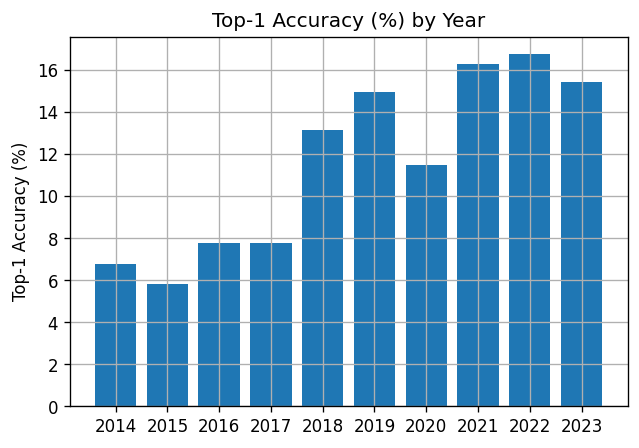

In [83]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['top1']*100)
ax.set_ylabel('Top‑1 Accuracy (%)')
ax.set_title('Top‑1 Accuracy (%) by Year')
plt.show()


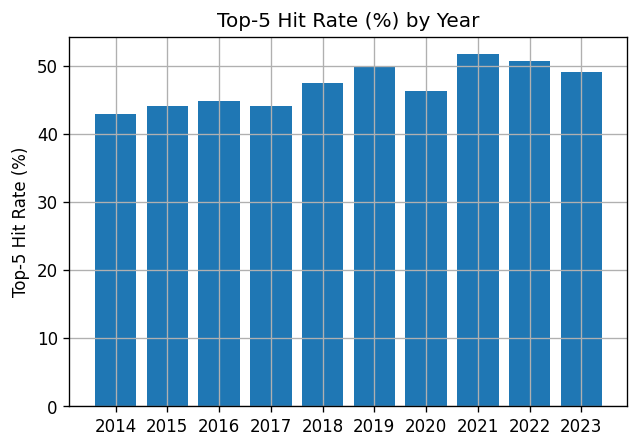

In [84]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['hit5']*100)
ax.set_ylabel('Top‑5 Hit Rate (%)')
ax.set_title('Top‑5 Hit Rate (%) by Year')
plt.show()


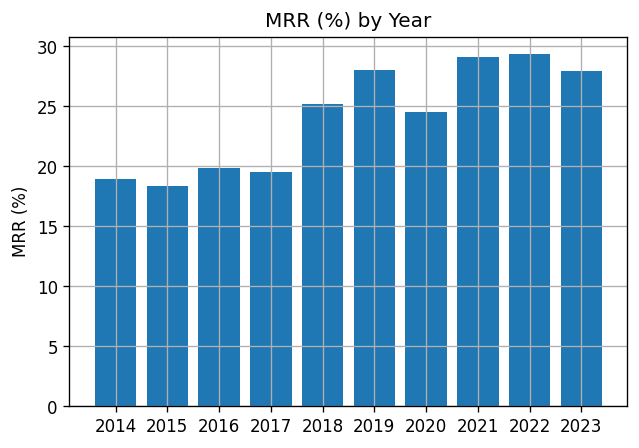

In [85]:

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['mrr']*100)
ax.set_ylabel('MRR (%)')
ax.set_title('MRR (%) by Year')
plt.show()


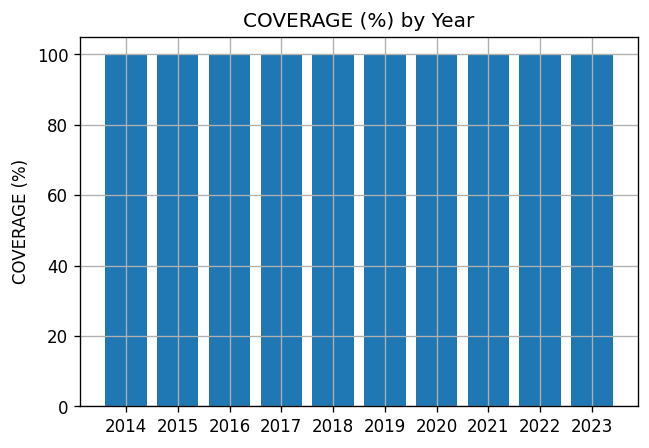

In [86]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['coverage']*100)
ax.set_ylabel('COVERAGE (%)')
ax.set_title('COVERAGE (%) by Year')
plt.show()

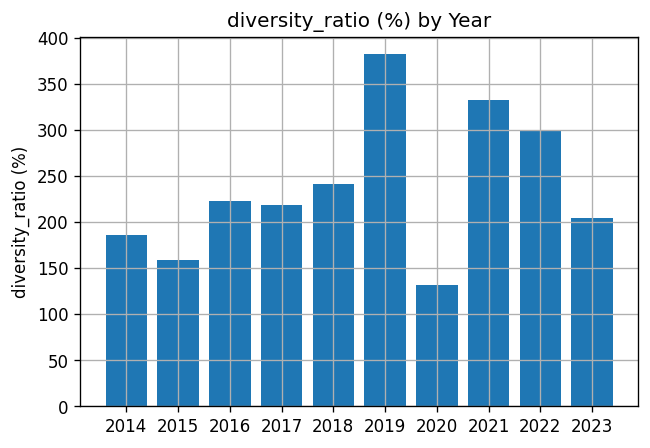

In [87]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(by_year['year'].astype(str), by_year['diversity_ratio']*100)
ax.set_ylabel('diversity_ratio (%)')
ax.set_title('diversity_ratio (%) by Year')
plt.show()

### 3.1 Coverage breakdown

In [88]:
# Analisi Coverage dettagliata (corretta)
print("📊 DETAILED COVERAGE ANALYSIS")
print("=" * 50)

# Calcola POI unici in modo corretto
predicted_pois_set = set()
for preds in df_all["prediction_norm"]:
    if isinstance(preds, list):
        predicted_pois_set.update(preds)

ground_truth_pois_set = set(df_all["ground_truth_norm"].unique())

# Filtra valori invalidi
predicted_pois_clean = {poi for poi in predicted_pois_set if poi and str(poi) != 'nan' and str(poi) != 'None'}
ground_truth_pois_clean = {poi for poi in ground_truth_pois_set if poi and str(poi) != 'nan' and str(poi) != 'None'}

print(f"POI distinct in predictions: {len(predicted_pois_clean)}")
print(f"POI distinct in ground-truth: {len(ground_truth_pois_clean)}")

# Coverage corretto
true_coverage = len(predicted_pois_clean) / len(ground_truth_pois_clean) if len(ground_truth_pois_clean) > 0 else 0
print(f"Catalogue Coverage: {true_coverage:.2%}")

# Analisi della sovrapposizione
overlap = predicted_pois_clean.intersection(ground_truth_pois_clean)
only_predicted = predicted_pois_clean - ground_truth_pois_clean
only_ground_truth = ground_truth_pois_clean - predicted_pois_clean

print(f"\n🔄 POI OVERLAP ANALYSIS:")
print(f"  POI in both prediction & ground-truth: {len(overlap)}")
print(f"  POI only in predictions: {len(only_predicted)}")
print(f"  POI only in ground-truth: {len(only_ground_truth)}")

if len(only_predicted) > 0 and len(only_predicted) <= 20:
    print(f"\n🔍 Examples of POI only in predictions:")
    for poi in list(only_predicted)[:10]:
        print(f"    • {poi}")

if len(only_ground_truth) > 0 and len(only_ground_truth) <= 20:
    print(f"\n🎯 Examples of POI only in ground-truth:")
    for poi in list(only_ground_truth)[:10]:
        print(f"    • {poi}")

# Metriche aggiuntive
recall_coverage = len(overlap) / len(ground_truth_pois_clean) if len(ground_truth_pois_clean) > 0 else 0
precision_coverage = len(overlap) / len(predicted_pois_clean) if len(predicted_pois_clean) > 0 else 0

print(f"\n📈 ADDITIONAL COVERAGE METRICS:")
print(f"  Coverage Recall: {recall_coverage:.2%} (fraction of true POI covered)")
print(f"  Coverage Precision: {precision_coverage:.2%} (fraction of predicted POI that exist)")

# Se il coverage è troppo alto, indica un problema nei dati
if true_coverage > 2.0:
    print(f"\n⚠️  HIGH COVERAGE WARNING:")
    print(f"  Coverage = {true_coverage:.1f}x suggests model predicts many non-existent POI")
    print(f"  This could indicate data quality issues or model hallucination")

📊 DETAILED COVERAGE ANALYSIS
POI distinct in predictions: 154
POI distinct in ground-truth: 22
Catalogue Coverage: 700.00%

🔄 POI OVERLAP ANALYSIS:
  POI in both prediction & ground-truth: 22
  POI only in predictions: 132
  POI only in ground-truth: 0

📈 ADDITIONAL COVERAGE METRICS:
  Coverage Recall: 100.00% (fraction of true POI covered)
  Coverage Precision: 14.29% (fraction of predicted POI that exist)

⚠️  HIGH COVERAGE WARNING:
  Coverage = 7.0x suggests model predicts many non-existent POI
  This could indicate data quality issues or model hallucination


## 4. Error analysis – overview

In questa sezione valutiamo **dove** e **perché** il modello sbaglia, seguendo tre filoni:

1. **Worst-performing POI pairs**  
   Scopriamo quali coppie `ground-truth → first_pred` generano il maggior numero di errori.

2. **Confusion matrix per subset**  
   Heat-map delle frequenze (o tasso d’errore) su un sotto-insieme di POI di interesse
   (ad es. i 20 più visitati o solo l’anno 2020).

3. **Explainability (SHAP / LIME)**  
   Analisi dei fattori testuali nella colonna `history` che portano a una predizione
   sbagliata. Qui mostriamo un prototipo basato su LIME; lo script è modulare
   e può essere sostituito da SHAP se usi modelli compatibili.


,ground_truth_norm,first_pred,errors
74,castelvecchio,museo miniscalchi,18500
124,duomo,palazzo della ragione,17626
380,teatro romano,museo miniscalchi,15125
318,san zeno,museo lapidario,13848
68,castelvecchio,duomo,12517
90,castelvecchio,verona tour,11738
77,castelvecchio,palazzo della ragione,11234
119,duomo,museo conte,11130
89,castelvecchio,torre lamberti,10146
72,castelvecchio,museo conte,9886


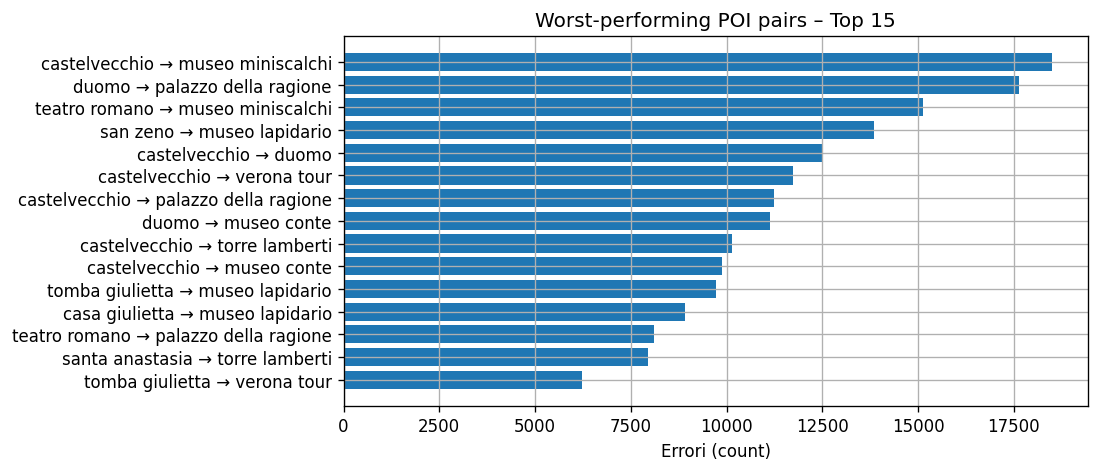

In [89]:
# ---------------------------------------------------------------------
# 4.1 Worst-performing POI pairs (Top-N) – FIX
# ---------------------------------------------------------------------
# filtro righe con errore Top-1
ERR = df_all.assign(first_pred=df_all["prediction_norm"].str[0])
ERR = ERR[~ERR["hit@1"]]           # equivalente a query("`hit@1` == False")

# conteggia coppie ground-truth → first_pred
pairs = (
    ERR.groupby(["ground_truth_norm", "first_pred"])
        .size()
        .reset_index(name="errors")
        .sort_values("errors", ascending=False)
        .head(15)          # Top-15 coppie
)

display(pairs)

# barplot (opzionale)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    pairs.apply(lambda r: f"{r['ground_truth_norm']} → {r['first_pred']}", axis=1),
    pairs["errors"]
)
ax.set_xlabel("Errori (count)")
ax.set_title("Worst-performing POI pairs – Top 15")
ax.invert_yaxis()
plt.show()


In [90]:
def safe_parse_prediction_debug(x, debug_mode=False):
    """
    Advanced parsing function with debug capabilities.
    Extends the basic safe_parse_prediction with diagnostic information.
    """
    if pd.isna(x) or x is None:
        if debug_mode:
            return [], "empty_or_nan"
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        if debug_mode:
            return x, "already_list"
        return x
    
    # Se è una stringa
    if isinstance(x, str):
        # Rimuovi spazi extra
        x = x.strip()
        
        # Se sembra JSON
        if (x.startswith('[') and x.endswith(']')):
            try:
                parsed = ast.literal_eval(x)
                if isinstance(parsed, list):
                    if debug_mode:
                        return parsed, "ast_literal_eval"
                    return parsed
            except (ValueError, SyntaxError):
                pass
                
            # Prova con json.loads
            try:
                parsed = json.loads(x)
                if isinstance(parsed, list):
                    if debug_mode:
                        return parsed, "json_loads"
                    return parsed
            except json.JSONDecodeError:
                pass
        
        # Se contiene delle virgole, prova a fare split
        if ',' in x:
            # Rimuovi eventuali parentesi quadre
            clean_x = x.strip('[]')
            # Split e clean
            items = [item.strip().strip('"').strip("'") for item in clean_x.split(',')]
            # Filtra elementi vuoti
            items = [item for item in items if item]
            if items:
                if debug_mode:
                    return items, "comma_split"
                return items
        
        # Se è una singola stringa, ritornala come lista
        if x:
            if debug_mode:
                return [x], "single_string"
            return [x]
    
    # Fallback: converti in stringa e prova di nuovo
    if debug_mode:
        result, reason = safe_parse_prediction_debug(str(x), debug_mode=True)
        return result, f"fallback_to_str_{reason}"
    return safe_parse_prediction_debug(str(x))

In [91]:
def analyze_prediction_issues(df, sample_size=100):
    """Analizza i problemi nel parsing delle predizioni"""
    print("🔍 ANALYZING PREDICTION PARSING ISSUES")
    print("=" * 50)
    
    # Campiona alcune righe per analisi dettagliata
    sample_df = df.head(sample_size)
    parsing_stats = {}
    failed_examples = []
    
    for idx, row in sample_df.iterrows():
        pred_raw = row['prediction']
        parsed_result, reason = safe_parse_prediction_debug(pred_raw, debug_mode=True)
        
        parsing_stats[reason] = parsing_stats.get(reason, 0) + 1
        
        # Colleziona esempi di fallimenti
        if len(parsed_result) == 0 and not pd.isna(pred_raw):
            failed_examples.append({
                'index': idx,
                'raw_prediction': str(pred_raw)[:100] + ('...' if len(str(pred_raw)) > 100 else ''),
                'reason': reason
            })
    
    print(f"Parsing statistics (sample of {len(sample_df)} rows):")
    for reason, count in sorted(parsing_stats.items()):
        percentage = count / len(sample_df) * 100
        print(f"  {reason:>20s}: {count:>3d} ({percentage:>5.1f}%)")
    
    if failed_examples:
        print(f"\n❌ Failed parsing examples (first 5):")
        for i, example in enumerate(failed_examples[:5]):
            print(f"  {i+1}. Row {example['index']} ({example['reason']}): {example['raw_prediction']}")
    
    return parsing_stats, failed_examples

print("✅ Analysis function defined")

✅ Analysis function defined


In [92]:
def ultra_robust_parse_prediction(x):
    """
    Versione ultra-robusta del parser che prova ogni strategia possibile
    per estrarre predizioni valide dai dati.
    """
    if pd.isna(x) or x is None:
        return []
    
    # Se è già una lista
    if isinstance(x, list):
        # Filtra elementi vuoti dalla lista
        return [item for item in x if item and str(item).strip()]
    
    # Se non è una stringa, convertilo
    if not isinstance(x, str):
        x = str(x)
    
    x = x.strip()
    if not x or x.lower() in ['nan', 'none', 'null']:
        return []
    
    # Strategia 1: ast.literal_eval
    try:
        result = ast.literal_eval(x)
        if isinstance(result, list):
            return [item for item in result if item and str(item).strip()]
        elif result:  # Singolo elemento non-vuoto
            return [result]
    except (ValueError, SyntaxError):
        pass
    
    # Strategia 2: JSON parsing
    try:
        result = json.loads(x)
        if isinstance(result, list):
            return [item for item in result if item and str(item).strip()]
        elif result:  # Singolo elemento non-vuoto
            return [result]
    except (json.JSONDecodeError, ValueError):
        pass
    
    # Strategia 3: Rimozione caratteri problematici + splitting
    # Rimuovi caratteri di lista comuni
    cleaned = x
    for char in ['[', ']', '(', ')', '{', '}']:
        cleaned = cleaned.replace(char, '')
    
    # Rimuovi virgolette multiple
    cleaned = re.sub(r'["\']', '', cleaned)
    
    # Prova split per virgole
    if ',' in cleaned:
        items = [item.strip() for item in cleaned.split(',') if item.strip()]
        if items:
            return items
    
    # Strategia 4: Split per altri separatori
    for sep in [';', '|', '\n', '\t']:
        if sep in cleaned:
            items = [item.strip() for item in cleaned.split(sep) if item.strip()]
            if len(items) > 1:  # Solo se produce più elementi
                return items
    
    # Strategia 5: Regex per trovare pattern di lista
    # Pattern come: "item1", "item2", "item3"
    quoted_pattern = r'"([^"]+)"'
    matches = re.findall(quoted_pattern, x)
    if len(matches) > 1:
        return matches
    
    # Pattern come: item1, item2, item3 (senza virgolette)
    if ',' in cleaned:
        items = [item.strip() for item in cleaned.split(',') if item.strip()]
        if items:
            return items
    
    # Strategia 6: Se tutto fallisce, ritorna come singolo elemento se non vuoto
    if cleaned and cleaned not in ['nan', 'none', 'null', '[]', '{}']:
        return [cleaned]
    
    return []

print("✅ Ultra-robust parser defined")

✅ Ultra-robust parser defined
